In [91]:
# -*- coding: utf-8 -*-
import os
import sys
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib
import matplotlib as mpl
from shapely.geometry import Polygon, MultiPolygon
from shapely.geometry import LineString, Point, box
from shapely.ops import split, unary_union
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.patches import Rectangle
from matplotlib.lines import Line2D
from matplotlib.patches import FancyArrowPatch
from matplotlib.patches import Wedge, Patch, Circle
from matplotlib.colors import Normalize
from matplotlib import cm
from matplotlib.cm import ScalarMappable
from matplotlib.patches import FancyArrowPatch
from matplotlib.colors import Normalize, LinearSegmentedColormap
from matplotlib.patches import Circle
from matplotlib.offsetbox import AnchoredOffsetbox, VPacker, HPacker, TextArea, DrawingArea
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
import matplotlib.image as mpimg
import matplotlib as mpl
import geopandas as gpd
mpl.rcParams['mathtext.default'] = 'regular'
import matplotlib.image as mpimg


In [92]:
# 中文到英文映射
ch_en_map = {
    "北京市": "Beijing", "天津市": "Tianjin", "上海市": "Shanghai", "重庆市": "Chongqing",
    "河北省": "Hebei", "山西省": "Shanxi", "内蒙古自治区": "Inner Mongolia", "辽宁省": "Liaoning",
    "吉林省": "Jilin", "黑龙江省": "Heilongjiang", "江苏省": "Jiangsu", "浙江省": "Zhejiang",
    "安徽省": "Anhui", "福建省": "Fujian", "江西省": "Jiangxi", "山东省": "Shandong",
    "河南省": "Henan", "湖北省": "Hubei", "湖南省": "Hunan", "广东省": "Guangdong",
    "广西壮族自治区": "Guangxi", "海南省": "Hainan", "四川省": "Sichuan", "贵州省": "Guizhou",
    "云南省": "Yunnan", "西藏自治区": "Tibet", "陕西省": "Shaanxi", "甘肃省": "Gansu",
    "青海省": "Qinghai", "宁夏回族自治区": "Ningxia", "新疆维吾尔自治区": "Sinkiang",
    "台湾省": "Taiwan", "香港特别行政区": "Hong Kong", "澳门特别行政区": "Macau"
}

In [93]:
# ======================================== 0. 控制台 UTF-8 & 中文字体 =====================================
if os.name == 'nt':
    os.system('chcp 65001 >nul')
    if hasattr(sys.stdout, "reconfigure"):
        sys.stdout.reconfigure(encoding='utf-8')

matplotlib.rcParams['font.family'] = 'sans-serif'
matplotlib.rcParams['font.sans-serif'] = ['Arial', 'SimHei']
matplotlib.rcParams['axes.unicode_minus'] = False

# —— 1. 路径设定 ——  
prov_shp = r"D:\Research\China_E_C\Map\CN_Map\CN_Province.shp"
prefecture_shp = r"D:\Research\China_E_C\Map\CN_Map_WGS1984\CN_Prefecture.shp"
nine_shp = r"D:\Research\China_E_C\Map\CN_Map\Jiu_Duan_Xian.shp"
prefecture_map_path = r"D:\Research\China_E_C\Map\CN_Map_WGS1984\prefecture_area_cn_pinyin_en.xlsx"
    

out_dir = r"D:\Research\China_E_C\Paper_Fig\Fig_4cases\EC_Network\CN50"
os.makedirs(out_dir, exist_ok=True)

In [94]:
#============================== 2. 读取 & 投影 ===============================  
# 读取省级数据
prov = gpd.read_file(prov_shp, engine='fiona', encoding='utf-8')
# 读取地级市级数据
prefecture = gpd.read_file(prefecture_shp, engine='fiona', encoding='utf-8')
# 读取地级市中英文映射
pref_map_df = pd.read_excel(prefecture_map_path)
# 从映射文件中提取列D和列J（索引为3和9）
pref_mapping = pref_map_df.iloc[:, [3, 9]].copy()
pref_mapping.columns = ['Prefecture_CN', 'GAMS_prefecture']
    
nine = gpd.read_file(nine_shp, engine='fiona', encoding='utf-8')

# 2.1 用于切分的地理 CRS（WGS1984）
prefecture_geo = prefecture.to_crs(epsg=4326)

# 2.2 投影到 EPSG:2343，用于最终绘图
prov_2343 = prov.to_crs(epsg=2343)
prefecture_2343 = prefecture.to_crs(epsg=2343)
nine_2343 = nine.to_crs(epsg=2343)

# 2.3 剔除省级底图中的小岛/碎片，用于控制主图显示范围
def remove_small_islands(geom, min_area=5e9):
    if geom is None or geom.is_empty:
        return geom

    if isinstance(geom, MultiPolygon):
        parts = [p for p in geom.geoms if p.area > min_area]
        if not parts:
            return geom
        return parts[0] if len(parts) == 1 else MultiPolygon(parts)

    return geom if geom.area > min_area else geom

prov_2343["geometry"] = prov_2343["geometry"].buffer(0)
prov_2343["geometry"] = prov_2343["geometry"].apply(
    lambda g: remove_small_islands(g, min_area=5e9)
)

# 地级市图层也做一次几何修复，避免无效几何影响绘图
prefecture_2343["geometry"] = prefecture_2343["geometry"].buffer(0)
prefecture_2343 = prefecture_2343[~prefecture_2343["geometry"].is_empty].copy()



(-2244505.404526481, 2720859.3588773767, 2012980.3232581033, 6098749.965823658)

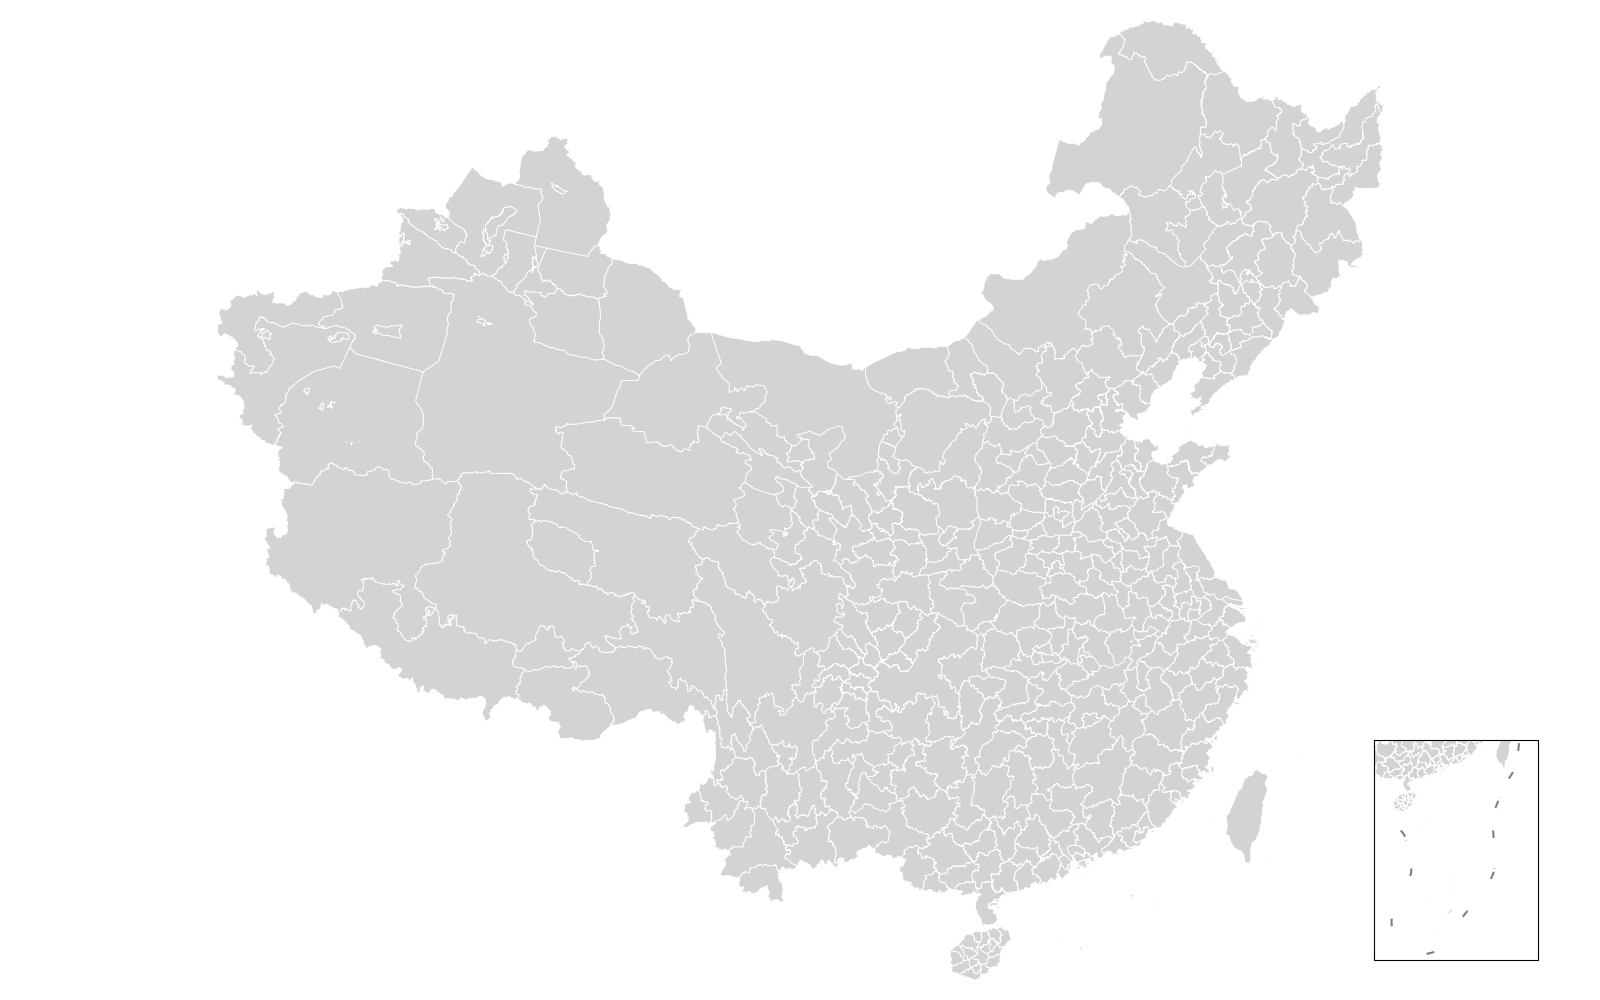

In [95]:
# ============================ 3. 绘制主图 + 九段线 inset ==============================

# 说明：
# 1）不要用 prefecture_2343.total_bounds 控制主图范围；
# 2）主图范围用清理后的 prov_2343.total_bounds，这样比例和之前省际图一致；
# 3）继续使用 fig.add_axes 创建九段线 inset，避免 constrained_layout + inset_axes 报错。

try:
    from IPython import get_ipython
    ip = get_ipython()
    if ip is not None:
        ip.run_line_magic("config", "InlineBackend.print_figure_kwargs = {'bbox_inches': None}")
except Exception:
    pass

fig, ax = plt.subplots(figsize=(16, 10), constrained_layout=False)
fig.subplots_adjust(left=0.02, right=0.98, bottom=0.02, top=0.98)

from matplotlib.backends.backend_agg import FigureCanvasAgg as FigureCanvas
FigureCanvas(fig)
fig.canvas.draw()

albers_proj = 'EPSG:2343'

# 3.1 主图：地级市界背景
prefecture_2343.plot(
    ax=ax,
    facecolor="lightgrey",
    edgecolor="white",
    linewidth=0.6,
    zorder=1
)

ax.set_axis_off()

# 关键：主图范围使用省级底图范围，而不是地级市 total_bounds
# 这样地图比例会和之前省际图保持一致
minx, miny, maxx, maxy = prov_2343.total_bounds

xrange_ = maxx - minx
yrange_ = maxy - miny

ax.set_xlim(minx - 0.00 * xrange_, maxx + 0.00 * xrange_)
ax.set_ylim(miny - 0.00 * yrange_, maxy + 0.00 * yrange_)

# 3.2 九段线 inset
bbox_geo = box(106.5, 2.8, 123.0, 24.5)

bbox_2343 = gpd.GeoSeries(
    [bbox_geo],
    crs=4326
).to_crs(epsg=2343).iloc[0]

prefecture_crop = prefecture_2343[prefecture_2343.intersects(bbox_2343)].copy()
nine_crop = nine_2343[nine_2343.intersects(bbox_2343)].copy()

# 使用 fig.add_axes，避免 inset_axes 引起 renderer / tight_bbox 报错
axins = fig.add_axes([0.82, 0.04, 0.18, 0.22])

prefecture_crop.plot(
    ax=axins,
    facecolor="lightgrey",
    edgecolor="white",
    linewidth=0.6,
    zorder=1
)

nine_crop.plot(
    ax=axins,
    color="gray",
    linewidth=1.5,
    linestyle="--",
    zorder=2
)

# 固定 inset 范围
minx_i, miny_i, maxx_i, maxy_i = bbox_2343.bounds
axins.set_xlim(minx_i, maxx_i)
axins.set_ylim(miny_i, maxy_i)

axins.set_xticks([])
axins.set_yticks([])
axins.set_axis_off()

rect = Rectangle(
    (0, 0), 1, 1,
    transform=axins.transAxes,
    fill=False,
    edgecolor="black",
    linewidth=0.8,
    zorder=10,
    clip_on=False
)
axins.add_patch(rect)

ax.axis("off")

In [96]:
# ============================== 4. 基于地级市将内蒙古分为蒙西／蒙东两块 =================================

# 4.1 读取并投影地级市 shp（CN_Prefecture.shp）
city = gpd.read_file(prefecture_shp, encoding='utf-8').to_crs(epsg=2343)

# 4.2 筛选“内蒙古自治区”下属所有地级市
im_city = city[city['省']=="内蒙古自治区"].copy()

# 4.3 定义蒙西／蒙东的地市名单
east_list = ["赤峰市","通辽市","兴安盟","呼伦贝尔市"]

west_list = [c for c in im_city['市'].unique() if c not in east_list]

# 4.4 新增 region 列，然后 dissolve 合并
im_city['region'] = im_city['市'].apply(
    lambda s: 'W_InnerMongo' if s in west_list
              else ('E_InnerMongo' if s in east_list else None)
)

im_west = (
    im_city[im_city['region']=="W_InnerMongo"]
    .dissolve(by='region')
    .reset_index()   # 把 region 提升为一列
)

im_east = (
    im_city[im_city['region']=="E_InnerMongo"]
    .dissolve(by='region')
    .reset_index()
)

In [97]:
# ============================== 5. 绘制电网区域边框 ==============================
prov_2343['province_cn'] = prov_2343['省']
def remove_small_islands(geom, min_area=5e10):
    """
    过滤掉面积小于 min_area 的小岛。
    geom: Polygon 或 MultiPolygon
    """
    if isinstance(geom, MultiPolygon):
        parts = [p for p in geom.geoms if p.area > min_area]
        if not parts:
            return geom
        return parts[0] if len(parts)==1 else MultiPolygon(parts)
    # 单面片
    return geom if geom.area > min_area else geom

def remove_small_parts(geom, min_area=5e8):
        if isinstance(geom, MultiPolygon):
            parts = [p for p in geom.geoms if p.area > min_area]
            if len(parts) == 0:
                return None
            elif len(parts) == 1:
                return parts[0]
            else:
                return MultiPolygon(parts)
        elif isinstance(geom, Polygon):
            return geom if geom.area > min_area else None
        return geom

# —— 4.5 定义电网区域及样式 ——  
grid_regions = {
    'NE': { 'province_cn': ["辽宁省","吉林省","黑龙江省"],
            'use_im_east': True,
            'style': dict(edgecolor="#4e79a7", linewidth=2, linestyle='--') },

    'NC': { 'province_cn': ["山东省","山西省","河北省","天津市","北京市"],
            'use_im_west': True,
            'style': dict(edgecolor="#2a4651", linewidth=2, linestyle='--') },

    'EC': { 'province_cn': ["上海市","江苏省","浙江省","安徽省","福建省"],
            'style': dict(edgecolor="#5e8440", linewidth=2, linestyle='--') },

    'HC': { 'province_cn': ["湖南省","湖北省","江西省","河南省"],
            'style': dict(edgecolor="#c7a76c", linewidth=2, linestyle='--') },

    'SW': { 'province_cn': ["四川省","重庆市","西藏自治区"],
            'style': dict(edgecolor="#841e2a", linewidth=2, linestyle='--') },

    'NW': { 'province_cn': ["陕西省","甘肃省","宁夏回族自治区","青海省","新疆维吾尔自治区"],
            'style': dict(edgecolor="#c55274", linewidth=2, linestyle='--') },

    'SC': { 'province_cn': ["广东省","广西壮族自治区","海南省","云南省","贵州省"],
            'style': dict(edgecolor="#347219", linewidth=2, linestyle='--') }
}

# 构造每个区域的合并几何并带上样式
grid_borders = []
for code, info in grid_regions.items():
    # 取普通省份的 geometry
    geoms = prov_2343[prov_2343['province_cn'].isin(info['province_cn'])].geometry.tolist()
    # 加蒙东/蒙西
    if info.get('use_im_east'):
        geoms.append(im_east.geometry.iloc[0])
    if info.get('use_im_west'):
        geoms.append(im_west.geometry.iloc[0])
    # 合并并过滤小岛
    if geoms:
        merged = unary_union(geoms)
        area_threshold = 5e9 if code == "SC" else 5e10
        merged = remove_small_islands(merged, min_area=area_threshold)
        # 一次性 append region, geometry, style
        grid_borders.append({
            'region': code,
            'geometry': merged,
            'style': info['style']
        })

grid_gdf = gpd.GeoDataFrame(grid_borders, crs=prov_2343.crs)

# 绘制省级边界（黑色线条，粗细为1）
prov_2343.boundary.plot(
    ax=ax,
    edgecolor='white',
    linewidth=0.85,   # 稍微细一点
    zorder=2
)

# 按区域分别绘制
for _, row in grid_gdf.iterrows():
    gpd.GeoSeries(row.geometry).boundary.plot(
        ax=ax, zorder=3, **row['style']
    )

legend_handles = []
for code, info in grid_regions.items():
    style = info['style']
    # 用 Line2D 构造一个仅用于图例的线条示例
    line = Line2D(
        [0], [0],
        color=style['edgecolor'],
        linewidth=style['linewidth'],
        linestyle=style['linestyle']
    )
    legend_handles.append((line, code))

# 拆解 handles, labels
handles, labels = zip(*legend_handles)

# 在图上添加图例
leg =ax.legend(
    handles, labels,
    title="Province Region",
    loc="lower left",
    bbox_to_anchor=(-0.135, 0.173),
    frameon=False,
    edgecolor='gray',
    ncol = 2,
    fontsize=15.8,
    columnspacing=2,
    labelspacing=0.7,
    title_fontsize=18.6
)
leg.get_title().set_fontweight('bold')
ax.add_artist(leg)


<Figure size 640x480 with 0 Axes>

In [98]:
# ============================== 6. CO2 Storage Capacity at Prefecture Level ==============================
# 数据来源：Stage3_fig.xlsx -> CS_Pref_50，单位 Mt
# 省份简称映射：Prov_contrast.xlsx
# 地级市名称映射：prefecture_area_cn_pinyin_en.xlsx

stage3_fig_path = r"D:\Research\China_E_C\Paper_Fig\Fig_4cases\EC_Network\CN50\Stage_3_fig.xlsx"
prov_contrast_path = r"D:\Research\China_E_C\Map\CN_Map_WGS1984\Prov_contrast.xlsx"

# 6.1 读取地级市封存量数据：省份简称、GAMS城市名、封存量
cs_pref = pd.read_excel(
    stage3_fig_path,
    sheet_name="CS_Pref_50",
    header=None,
    names=["Prov_short", "GAMS_Prefecture", "Value"]
)
cs_pref["Prov_short"] = cs_pref["Prov_short"].astype(str).str.strip()
cs_pref["GAMS_Prefecture"] = cs_pref["GAMS_Prefecture"].astype(str).str.strip()
cs_pref["Value"] = pd.to_numeric(cs_pref["Value"], errors="coerce").fillna(0)

# 个别 GAMS 输出城市名与底图映射文件不一致时，在这里做手动别名修正
# 目前数据中 JS-Weian 对应江苏淮安 Huaian
pref_alias = {
    ("JS", "Weian"): "Huaian",
}
cs_pref["GAMS_Prefecture"] = cs_pref.apply(
    lambda r: pref_alias.get((r["Prov_short"], r["GAMS_Prefecture"]), r["GAMS_Prefecture"]),
    axis=1
)

# 6.2 读取省份简称映射，并转换为映射文件中的 GAMS_Province 名称
prov_contrast = pd.read_excel(prov_contrast_path)
prov_contrast["Prov_short"] = prov_contrast["Prov_short"].astype(str).str.strip()
prov_contrast["Prov_name"] = prov_contrast["Prov_name"].astype(str).str.strip()

cs_pref = cs_pref.merge(
    prov_contrast[["Prov_short", "Prov_name"]],
    on="Prov_short",
    how="left"
)

# 蒙东 / 蒙西在地级市底图映射文件中统一属于 InnerMongolia
cs_pref["GAMS_Province"] = cs_pref["Prov_name"].replace({
    "W_InnerMongolia": "InnerMongolia",
    "E_InnerMongolia": "InnerMongolia",
    "Inner Mongolia": "InnerMongolia",
})

unmatched_prov = cs_pref.loc[cs_pref["Prov_name"].isna(), "Prov_short"].unique()
if len(unmatched_prov) > 0:
    print("以下省份简称未在 Prov_contrast.xlsx 中匹配到：", unmatched_prov)

# 6.3 读取地级市中文 / GAMS 名称映射
pref_map_full = pd.read_excel(prefecture_map_path)

# 兼容此前代码：如果已经只读取了两列 pref_mapping，这里仍重新读取完整映射文件，便于同时匹配省份和城市
required_cols = ["Province_CN", "Prefecture_CN", "GAMS_Province", "GAMS_Prefecture"]
missing_cols = [c for c in required_cols if c not in pref_map_full.columns]
if missing_cols:
    raise KeyError(f"prefecture_area_cn_pinyin_en.xlsx 缺少必要列：{missing_cols}")

pref_map_full = pref_map_full[required_cols].dropna().copy()
for c in required_cols:
    pref_map_full[c] = pref_map_full[c].astype(str).str.strip()

# 6.4 将 CS_Pref_50 的 GAMS 省市名转换为底图中文省市名
cs_pref_map = cs_pref.merge(
    pref_map_full,
    on=["GAMS_Province", "GAMS_Prefecture"],
    how="left"
)

unmatched_pref = cs_pref_map[cs_pref_map["Prefecture_CN"].isna()].copy()
print(f">>> CS_Pref_50 中未匹配到中文地级市的记录数: {len(unmatched_pref)}")
if len(unmatched_pref) > 0:
    print(unmatched_pref[["Prov_short", "Prov_name", "GAMS_Province", "GAMS_Prefecture", "Value"]].head(20).to_string(index=False))

# 6.5 与地级市底图合并。用 省 + 市 双字段合并，避免同名城市误匹配
prefecture_2343 = prefecture_2343.copy()
pref_merged = prefecture_2343.merge(
    cs_pref_map[["Province_CN", "Prefecture_CN", "Value"]],
    left_on=["省", "市"],
    right_on=["Province_CN", "Prefecture_CN"],
    how="left"
)

# 没有封存量数据的城市按 0 Mt 处理
# pref_merged["Value"] = pref_merged["Value"].fillna(0)

# 6.6 构造绘图图层并过滤小碎片
plot_gdf = pref_merged[["省", "市", "geometry", "Value"]].copy()
plot_gdf = gpd.GeoDataFrame(plot_gdf, geometry="geometry", crs=prefecture_2343.crs)

if "remove_small_parts" not in globals():
    def remove_small_parts(geom, min_area=5e8):
        if geom is None or geom.is_empty:
            return None
        if isinstance(geom, MultiPolygon):
            parts = [p for p in geom.geoms if p.area > min_area]
            if len(parts) == 0:
                return None
            return parts[0] if len(parts) == 1 else MultiPolygon(parts)
        if isinstance(geom, Polygon):
            return geom if geom.area > min_area else None
        return geom

plot_gdf["geometry"] = plot_gdf["geometry"].apply(lambda g: remove_small_parts(g, min_area=5e8))
plot_gdf = plot_gdf.dropna(subset=["geometry"]).copy()

# 6.7 数据质量检查
matched_storage_city = (pref_merged["Value"] > 0).sum()
print(f">>> 地级市封存量 > 0 的城市数量: {matched_storage_city}")
print(f">>> 地级市底图数量: {len(pref_merged)}")
print(f">>> 最大地级市封存量: {plot_gdf['Value'].max():.3f} Mt")

# 6.8 绘制地级市封存量底色
# 注意：
# 1）保留无封存量城市为原始底图背景色 lightgrey；
# 2）地级市边界颜色与第 3 部分主图保持一致；
# 3）省界和电网区域边框重新叠加到最上层。

vmin = 0
vmax = np.ceil(plot_gdf["Value"].max() / 100) * 100
if vmax <= 0:
    vmax = 1

norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)

# 颜色方案
orig_cmap = mpl.colormaps["plasma_r"]
colors = orig_cmap(np.linspace(0, 1, 256))
colors[:, -1] = 0.42          # 透明度，和底图融合；可在 0.35-0.55 间调整
cmap_alpha = mpl.colors.ListedColormap(colors)

# 只绘制有封存量数据的城市，避免把无数据城市也染成 0 值颜色
plot_gdf_valid = plot_gdf[plot_gdf["Value"].notna()].copy()

plot_gdf_valid.plot(
    column="Value",
    cmap=cmap_alpha,
    norm=norm,
    linewidth=0,
    edgecolor="none",
    ax=ax,
    zorder=1.6
)

# 重新叠加地级市边界：与第 3 部分主图背景风格保持一致
prefecture_2343.boundary.plot(
    ax=ax,
    edgecolor="white",      # 与第 3 部分 edgecolor="grey" 一致
    linewidth=0.7,        # 与第 3 部分 linewidth=0.45 一致
    alpha=0.65,
    zorder=3.0
)

# 重新叠加省界：保持你第 5 部分的省界风格
prov_2343.boundary.plot(
    ax=ax,
    edgecolor="grey",
    linewidth=0.8,
    zorder=4.0
)

# 重新叠加电网区域边框：因为封存量填色后可能覆盖前面图层
if "grid_gdf" in globals():
    for _, row in grid_gdf.iterrows():
        gpd.GeoSeries(row.geometry, crs=prov_2343.crs).boundary.plot(
            ax=ax,
            zorder=5.0,
            **row["style"]
        )

# 重新锁定主图范围，防止 GeoPandas plot 自动改变地图比例
minx, miny, maxx, maxy = prov_2343.total_bounds
xrange_ = maxx - minx
yrange_ = maxy - miny

ax.set_xlim(minx, maxx)
ax.set_ylim(miny, maxy)
ax.set_axis_off()

# 6.9 Colorbar，单位 Mt
sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap_alpha)
sm._A = []

# 使用 fig.add_axes，避免 constrained_layout / inset_axes 在部分环境中触发 renderer 问题
# 清理重复运行该单元格时残留的旧 colorbar axes。
# 本 Notebook 中除主地图 ax 和南海插图 axins 外，
# 其余 axes 都视为旧 colorbar 并删除。
for _extra_ax in list(fig.axes):
    if _extra_ax is not ax and _extra_ax is not axins:
        _extra_ax.remove()

# 不再使用 inset_axes。
# 直接根据主地图 axes 的最终位置创建独立 colorbar axes。
fig.canvas.draw()

_ax_pos_for_cbar = ax.get_position().frozen()

# ============================== Colorbar controls ==============================

# colorbar 与主地图之间的水平距离
CBAR_GAP = 0.028

# colorbar 宽度，使用 Figure 坐标
CBAR_WIDTH = 0.022

# colorbar 长度占主地图高度的比例
CBAR_HEIGHT_RATIO = 0.52

_cbar_height = (
    _ax_pos_for_cbar.height
    * CBAR_HEIGHT_RATIO
)

# 让加长后的 colorbar 保持竖直居中
_cbar_bottom = (
    _ax_pos_for_cbar.y0
    + (_ax_pos_for_cbar.height - _cbar_height) / 2
    + 0.12
)

_cbar_left = (
    _ax_pos_for_cbar.x1
    + CBAR_GAP
)

cax = fig.add_axes([
    _cbar_left,
    _cbar_bottom,
    CBAR_WIDTH,
    _cbar_height,
])

cbar = plt.colorbar(
    sm,
    cax=cax,
    orientation="vertical"
)

cbar.ax.patch.set_facecolor("lightgrey")
cbar.outline.set_edgecolor("none")

cbar.ax.tick_params(
    axis="y",
    which="major",
    direction="in",
    labelsize=16,
    length=3.0,
    width=1.2,
)

cbar.set_label(
    "CO$_2$ Storage Capacity (Mt)",
    fontsize=22,
    labelpad=10,
)

print("CS_Pref_50 地级市封存量绘制完成，单位：Mt")

>>> CS_Pref_50 中未匹配到中文地级市的记录数: 0
>>> 地级市封存量 > 0 的城市数量: 142
>>> 地级市底图数量: 370
>>> 最大地级市封存量: 2486.540 Mt
CS_Pref_50 地级市封存量绘制完成，单位：Mt


<Figure size 640x480 with 0 Axes>

In [99]:
# ============================== 7. Intra-provincial Prefecture-to-Prefecture CO2 Transport Network ==============================
# 数据来源：Stage3_fig.xlsx -> U_Pef_acm_50
# 含义：同一省内地级市之间的碳传输管道建设容量
# 单位：Mt/yr
# 坐标：Prefecture_Centroids.xlsx 中的地级市中心点经纬度

prefecture_centroids_path = r"D:\Research\China_E_C\Map\CN_Map_WGS1984\Prefecture_Centroids.xlsx"

# 7.1 读取省内地级市间传输容量
df_pef_line = pd.read_excel(
    stage3_fig_path,
    sheet_name="U_Pef_acm_50",
    header=None,
    names=["Prov_short", "Origin", "Destination", "Cap"]
)

df_pef_line["Prov_short"] = df_pef_line["Prov_short"].astype(str).str.strip()
df_pef_line["Origin"] = df_pef_line["Origin"].astype(str).str.strip()
df_pef_line["Destination"] = df_pef_line["Destination"].astype(str).str.strip()
df_pef_line["Cap"] = pd.to_numeric(df_pef_line["Cap"], errors="coerce")

df_pef_line = df_pef_line.dropna(subset=["Prov_short", "Origin", "Destination", "Cap"]).copy()
df_pef_line = df_pef_line[df_pef_line["Cap"] > 0].copy()

# 7.2 读取地级市中心点经纬度
pref_cent = pd.read_excel(prefecture_centroids_path)
pref_cent = pref_cent.rename(columns={
    "Prons": "Prov_short",
    "Prefx": "Prefecture",
    "Lons": "Lon",
    "Lats": "Lat"
})

pref_cent["Prov_short"] = pref_cent["Prov_short"].astype(str).str.strip()
pref_cent["Prefecture"] = pref_cent["Prefecture"].astype(str).str.strip()
pref_cent["Lon"] = pd.to_numeric(pref_cent["Lon"], errors="coerce")
pref_cent["Lat"] = pd.to_numeric(pref_cent["Lat"], errors="coerce")

pref_cent = pref_cent.dropna(subset=["Prov_short", "Prefecture", "Lon", "Lat"]).copy()

# 7.3 转为 EPSG:2343，与主图一致
pref_cent_gdf = gpd.GeoDataFrame(
    pref_cent,
    geometry=gpd.points_from_xy(pref_cent["Lon"], pref_cent["Lat"]),
    crs="EPSG:4326"
).to_crs(epsg=2343)

pref_point_dict = dict(
    zip(
        zip(pref_cent_gdf["Prov_short"], pref_cent_gdf["Prefecture"]),
        pref_cent_gdf.geometry
    )
)

# 7.4 完整性检查
origin_keys = set(zip(df_pef_line["Prov_short"], df_pef_line["Origin"]))
dest_keys = set(zip(df_pef_line["Prov_short"], df_pef_line["Destination"]))
cent_keys = set(pref_point_dict.keys())

missing_origin = sorted(origin_keys - cent_keys)
missing_dest = sorted(dest_keys - cent_keys)

if missing_origin:
    print("以下起点城市未在 Prefecture_Centroids.xlsx 中找到：", missing_origin[:20], "..." if len(missing_origin) > 20 else "")
if missing_dest:
    print("以下终点城市未在 Prefecture_Centroids.xlsx 中找到：", missing_dest[:20], "..." if len(missing_dest) > 20 else "")

# 7.5 线宽分段：与省际传输 U_Prv_acm_50 保持一致
pef_bins = [0, 2, 5, 10, 20]
pef_widths = [1.2, 1.8, 2.5, 3.1]

pef_labels = [
    r"$0 < U_{i,j}^{Pref} \leq 2$",
    r"$2 < U_{i,j}^{Pref} \leq 5$",
    r"$5 < U_{i,j}^{Pref} \leq 10$",
    r"$10 < U_{i,j}^{Pref} \leq 20$"
]

def get_pef_width(val, bins=pef_bins, widths=pef_widths):
    for upper, lw in zip(bins[1:], widths):
        if val <= upper:
            return lw
    return widths[-1]

# 7.6 绘制城市—城市传输管道
# 颜色可以按需要修改；这里用紫红色，与省际管道风格保持一致
pef_line_color = "#c02bb8"
pef_node_face = "white"
pef_node_edge = "black"

# 先画细线，再画粗线，避免粗线被细线覆盖
for _, row in df_pef_line.sort_values("Cap", ascending=True).iterrows():
    prov = row["Prov_short"]
    origin = row["Origin"]
    dest = row["Destination"]
    cap = row["Cap"]

    key_o = (prov, origin)
    key_d = (prov, dest)

    if key_o not in pref_point_dict or key_d not in pref_point_dict:
        print(f"[Skip] 缺少城市中心点坐标：{prov}-{origin} -> {dest}")
        continue

    p_o = pref_point_dict[key_o]
    p_d = pref_point_dict[key_d]
    lw = get_pef_width(cap)

    ax.plot(
        [p_o.x, p_d.x],
        [p_o.y, p_d.y],
        color=pef_line_color,
        linestyle="-",
        linewidth=lw,
        alpha=0.82,
        zorder=6
    )

# 7.7 绘制参与省内城市传输的城市中心点
used_pref_keys = sorted(origin_keys.union(dest_keys))
xs, ys = [], []

for key in used_pref_keys:
    if key in pref_point_dict:
        pt = pref_point_dict[key]
        xs.append(pt.x)
        ys.append(pt.y)

ax.scatter(
    xs,
    ys,
    s=18,
    facecolor=pef_node_face,
    edgecolor=pef_node_edge,
    linewidth=0.8,
    zorder=7
)

# 7.8 重新叠加地级市边界、省界、电网区域边界，避免管线或点过度压住边界
prefecture_2343.boundary.plot(
    ax=ax,
    edgecolor="white",
    linewidth=0.6,
    alpha=0.55,
    zorder=5.5
)

prov_2343.boundary.plot(
    ax=ax,
    edgecolor="grey",
    linewidth=1,
    zorder=7.5
)

if "grid_gdf" in globals():
    for _, row in grid_gdf.iterrows():
        gpd.GeoSeries(row.geometry, crs=prov_2343.crs).boundary.plot(
            ax=ax,
            zorder=8.0,
            **row["style"]
        )

# 7.9 传输容量图例：与省际传输图例分段保持一致
legend_handles = []
legend_labels = []

for lbl, lw in zip(pef_labels, pef_widths):
    legend_handles.append(
        Line2D(
            [0, 1], [0, 0],
            color=pef_line_color,
            linestyle="-",
            linewidth=lw
        )
    )
    legend_labels.append(lbl)

leg_pef = ax.legend(
    handles=legend_handles,
    labels=legend_labels,
    title="Prefectural CO$_2$ Transport Capacity (Mt/yr)",
    loc="lower left",
    bbox_to_anchor=(-0.185, -0.015),
    frameon=False,
    ncol=2,
    columnspacing=1.5,
    labelspacing=1,
    fontsize=16,
    title_fontsize=18.6
)

leg_pef.get_title().set_fontweight("bold")
ax.add_artist(leg_pef)

# 7.10 重新锁定主图范围，防止 GeoPandas plot 自动改变显示比例
minx, miny, maxx, maxy = prov_2343.total_bounds
ax.set_xlim(minx, maxx)
ax.set_ylim(miny, maxy)
ax.set_axis_off()

print("U_Pef_acm_50 省内地级市间传输管道绘制完成，单位：Mt/yr")
print("省内城市间传输边数：", len(df_pef_line))
print("最大省内城市间传输容量：", round(df_pef_line["Cap"].max(), 3), "Mt/yr")

U_Pef_acm_50 省内地级市间传输管道绘制完成，单位：Mt/yr
省内城市间传输边数： 103
最大省内城市间传输容量： 21.481 Mt/yr


<Figure size 640x480 with 0 Axes>

In [100]:
# === 保存图片 ===
out_file = os.path.join(out_dir, "S3_Cnet_Pref"".png")
fig.savefig(out_file, dpi=600)  
print(f"图片已保存到: {out_file}")

from IPython.display import Image, display
display(Image(filename=out_file))

图片已保存到: D:\Research\China_E_C\Paper_Fig\Fig_4cases\EC_Network\CN50\S3_Cnet_Pref.png
